In [1]:
!kaggle datasets download -d pranavraikokte/covid19-image-dataset --force

Dataset URL: https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset
License(s): CC-BY-SA-4.0
100% 158M/158M [00:01<00:00, 128MB/s]



Dataset extracted!
Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.
Class Labels: {'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4064 - loss: 1.1139 - val_accuracy: 0.8485 - val_loss: 1.0058
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 932ms/step - accuracy: 0.6454 - loss: 0.9130 - val_accuracy: 0.8030 - val_loss: 0.5489
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 916ms/step - accuracy: 0.7371 - loss: 0.6257 - val_accuracy: 0.7121 - val_loss: 0.5143
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 930ms/step - accuracy: 0.7809 - loss: 0.4772 - val_accuracy: 0.7727 - val_loss: 0.3969
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 942ms/step - accuracy: 0.7849 - loss: 0.5113 - val_accuracy: 0.7121 - val_loss: 0.5462
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 926ms/step - accuracy: 0.8207 - loss: 0.4574 - val_accuracy: 0.8333 - val_loss: 0.3749
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 959ms/step - accuracy: 0.8884 - loss: 0.3409 - val_accuracy: 0.8939 - val_loss: 0.2896
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 943ms/step - accuracy: 0.8566 - loss: 0.3536 - val_accuracy: 0.8788 - val_loss: 0.

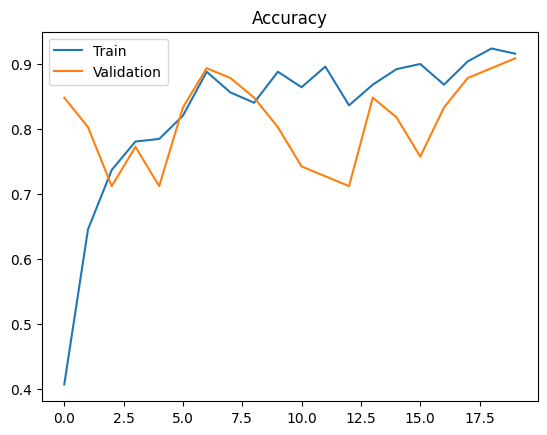

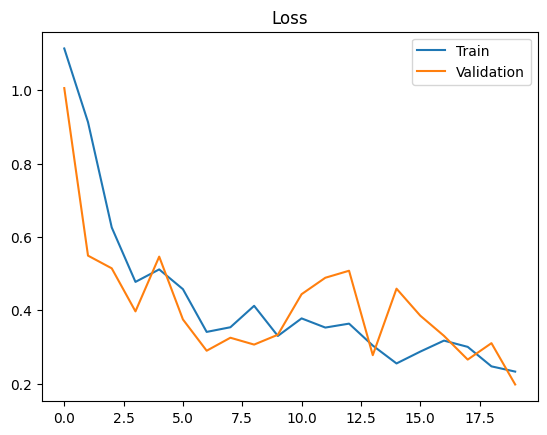

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Class: Covid


In [6]:
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image # Corrected import
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


# Extract dataset
with zipfile.ZipFile("covid19-image-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted!")


# Paths
train_dir = "dataset/Covid19-dataset/train"
test_dir = "dataset/Covid19-dataset/test"


# Data preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)


# Load data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

print("Class Labels:", train_generator.class_indices)


# Build model
model = Sequential([
    tf.keras.Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(train_generator.num_classes, activation='softmax')
])


# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


# Train
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator
)


# Evaluate
loss, acc = model.evaluate(test_generator)
print("Test Accuracy:", acc)


# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy")
plt.show()


# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Loss")
plt.show()


# Predict single image
img_path = "dataset/Covid19-dataset/test/Covid/0100.jpeg"

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_labels = list(train_generator.class_indices.keys())
predicted_class = class_labels[np.argmax(prediction)]

print("Predicted Class:", predicted_class)
